# Deep learning applied to gravitational lensing

## Import parameters

In [1]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


## Ellipticity

Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

## Shear

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

## Distribution of the dataset

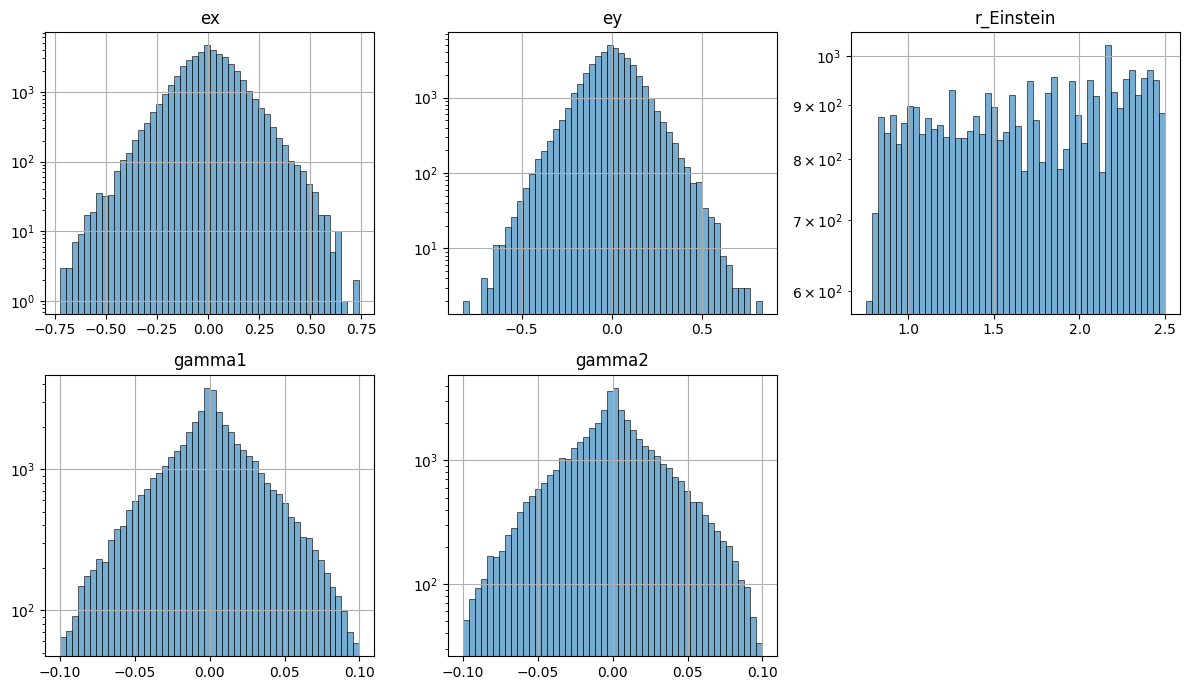

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()   
columns = ["ex", "ey", "r_Einstein", "gamma1", "gamma2"]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=50, alpha=0.6, log=True, edgecolor='black',linewidth=0.7)
    axes[i].set_title(col)
    axes[i].grid(True)

# axes[-2].axis("off")
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/Dataset_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## Images

In [6]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [7]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [8]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [9]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [10]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [11]:
import os
os.chdir("/home/mbatt")

In [12]:
image_index = 9

## Images raw

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_1/lens_12_source_1225_r_0.fits


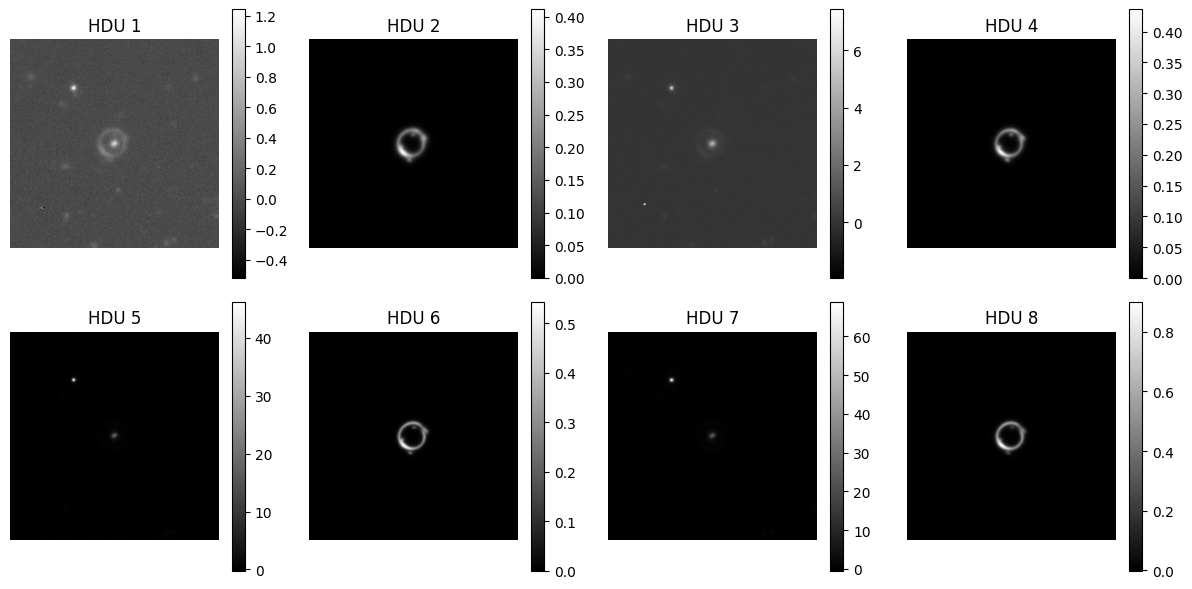

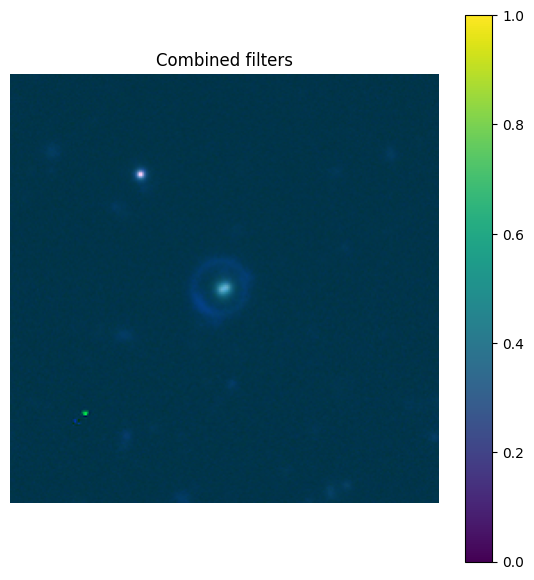

In [13]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import torch

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"HDU {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [14]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 8
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [15]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [16]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 8, 232 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location):
# #     if ima_file.split('/')[1] + '.pt' not in LL:
#     with fits.open(path_image + ima_file) as hdul:
#         c = random.randint(0, w1)
#         images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul))]
#         arr = np.stack(images, axis=0)
#         save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

## Images reformated

Found FITS: 43734
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_12_source_1225_r_0.fits.pt


/tmp/ipykernel_30219/4083360855.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)[::2]


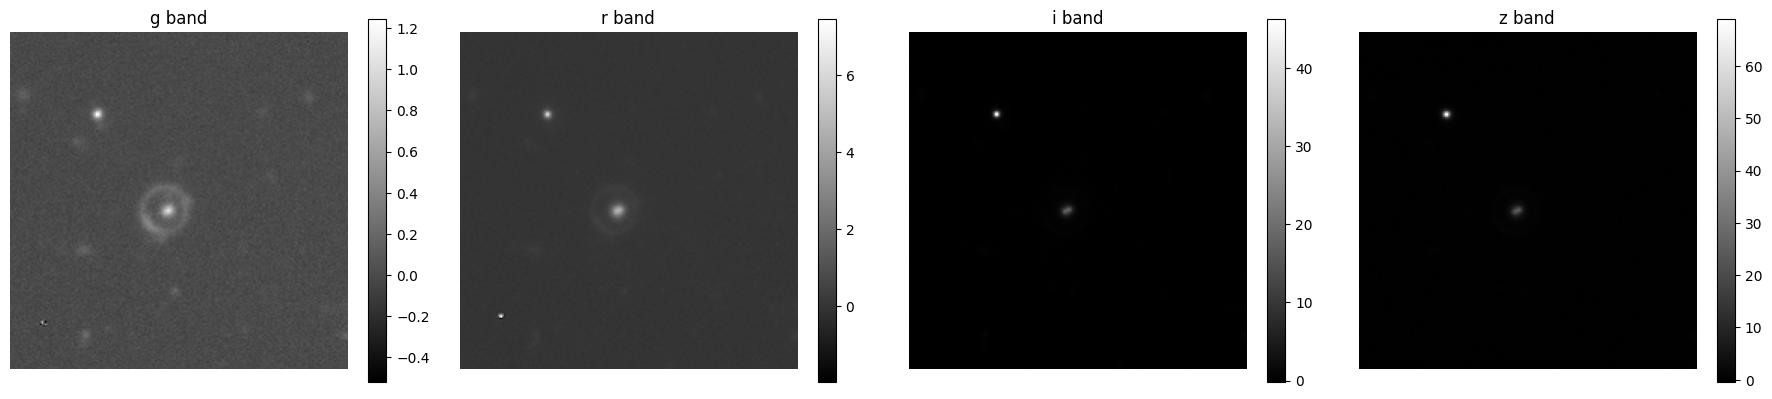

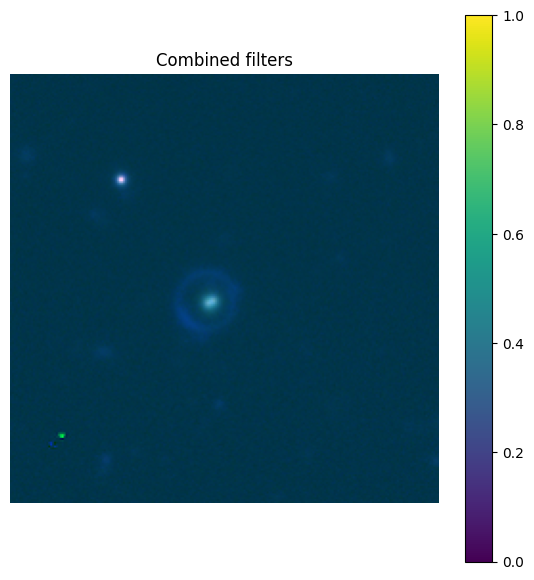

In [17]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)[::2]
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

# Deep learning models

In [18]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

# Normalization of the parameters

In [19]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [20]:
dff = dff.sample(frac=1, random_state=42)

In [21]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [22]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

## Load data

In [23]:
import os
os.chdir('/home/mbatt/gravitational_lensing')


In [24]:
!pwd

/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing


In [25]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [26]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

## Import Models

In [27]:
dinov2_vitb14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

Using cache found in /home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.5.1+cu121)
    Python  3.10.19 (you have 3.10.20)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (B

In [28]:
!conda env list


# conda environments:
#
dinov2                *  /home/mbatt/.conda/envs/dinov2
py_3_9_env               /home/mbatt/.conda/envs/py_3_9_env
base                     /usr/local/miniconda3
concerto                 /usr/local/miniconda3/envs/concerto



In [29]:
import torch
import torch.nn as nn

class LensingRegressor(nn.Module):
    def __init__(self, dinov2):
        super().__init__()
        
        # 4-band → 3-band adapter
        self.adapter = nn.Conv2d(4, 3, kernel_size=1)
        
        # Pretrained DINOv2 backbone
        self.backbone = dinov2
        
        # Freeze backbone at first
        for p in self.backbone.parameters():
            p.requires_grad = False
        
        # Regression head (DINOv2 ViT-B/14 outputs 768-dim CLS token)
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, 5)  # 3 outputs: R_E, ellipticity, shear
        )

    def forward(self, x):
        x = self.adapter(x)
        feats = self.backbone(x)  # CLS embedding
        return self.head(feats)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LensingRegressor(dinov2_vitb14).to(device)

In [30]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 86,778,644
Trainable parameters: 198,164


In [30]:
import torch
print(torch.cuda.is_available())


True


In [31]:
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def weighted_mse(pred, target, weights):
    loss = F.mse_loss(pred, target, reduction='none')
    loss = loss * weights
    return loss.mean()           

weights = torch.tensor([1, 1, 1, 1, 1], device=device)

In [32]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau


patience = 10
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)#, weight_decay=5e-4)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
# scheduler = torch.optim.lr_scheduler.StepLR(
#             optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)

best_val_loss = float('inf')
best_weights = None

In [34]:
import torch
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

warmup_epochs = 10
total_epochs = 100

warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=warmup_epochs
)

cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=total_epochs - warmup_epochs
)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

In [ ]:
import time 
start = time.time()
for epoch in range(100):

    # ---- TRAIN ----
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad() # It resets gradients to zero so they don’t accumulate from previous batches.
        outputs = model(xb)
        loss = weighted_mse(outputs, yb, weights)
        loss.backward() # computes gradients
        optimizer.step() # applies them to the model

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = weighted_mse(outputs, yb, weights)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))
    
    scheduler.step()
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()  
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
    
        # ---- EARLY STOPPING ----
    if early_stop_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

process_time = time.time() - start

Epoch 1: train=0.0349, val=0.0315
Epoch 2: train=0.0311, val=0.0297


In [ ]:
import os
os.chdir("/home/mbatt/gravitational_lensing/ViT_weights")

torch.save({
    "model": best_weights,
    "optimizer": optimizer.state_dict(),
    "epoch": epoch,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "process_time": process_time
}, "ViT_dinov2_1.pth")

In [ ]:
print(eeeee)

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing/ViT_weights")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load("ViT_model_7.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


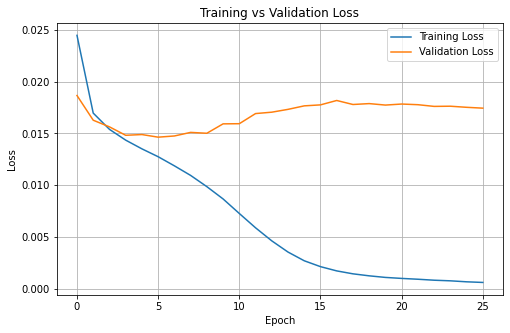

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/ViT_loss_3.png", dpi=300, bbox_inches="tight")
plt.show()


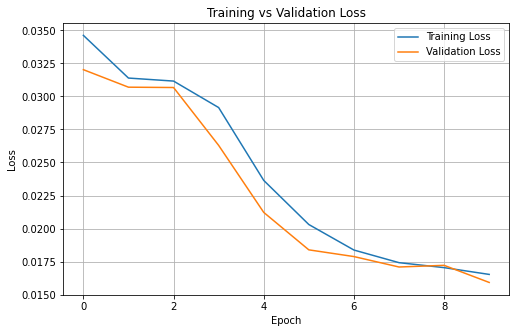

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/ViT_loss_3.png", dpi=300, bbox_inches="tight")
plt.show()


In [63]:
model.eval()
preds = []
targets = []

criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        # ---- Forward pass ----
        outputs = model(xb)

        preds.append(outputs.cpu())
        targets.append(yb.cpu())

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)

# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)


Per-parameter MSE: tensor([0.0109, 0.0243, 0.0236, 0.0028, 0.0021])
Per-parameter R2: [0.8681008070707321, 0.07492804527282715, 0.09210050106048584, 0.7098049819469452, 0.7275936603546143]


In [64]:
!python --version

Python 3.9.25


In [65]:
!nvidia-smi

Tue May 19 12:12:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:81:00.0 Off |                    0 |
|  0%   56C    P0            243W /  300W |    3102MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 69.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 110.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 61.4 MB/s  0:00:06:00:0100:01
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuff

  Using cached https://download.pytorch.org/whl/cu121/nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached https://download.pytorch.org/whl/nvidia_nccl_cu12-2.21.5-py3-none-manylinux2014_x86_64.whl (188.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 133.4 MB/s  0:00:0100:0100:01
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/nvidia_nvjitlink_cu12-12.9.86-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached https://download.pytorch.org/whl/nvidia_nvjitlink_cu12-12.9.86-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl (39.7 MB)
  Attempting uninstall: triton
    Found existing installation: triton 3.7.0
    Uninstalling triton-3.7.0:
      Successfully uninstalle

In [67]:
# !pip install xformers

In [40]:
!python3 -c "import torch; print(torch.__version__)"

2.5.1+cu121


In [68]:
!python3 -c "import torch; print(torch.__version__)"

2.5.1+cu121


In [69]:
!python3 -c "import torch, os; print(os.path.dirname(torch.__file__))"

/home/mbatt/.local/lib/python3.9/site-packages/torch


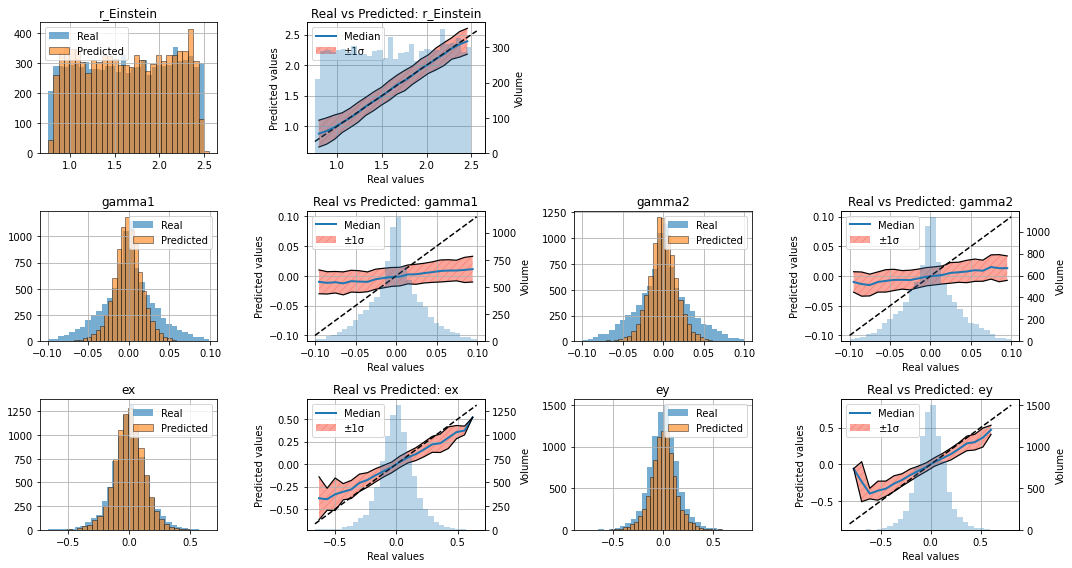

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}")
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
plt.show()


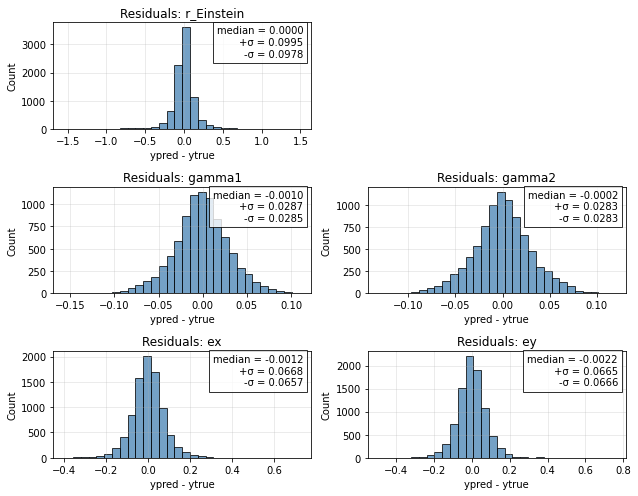

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(9, 7))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("ypred - ytrue")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"+σ = {sigma_plus[i]:.4f}\n"
        f"-σ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.97, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residus_sqrt_images_first.png", dpi=300, bbox_inches="tight")
plt.show()

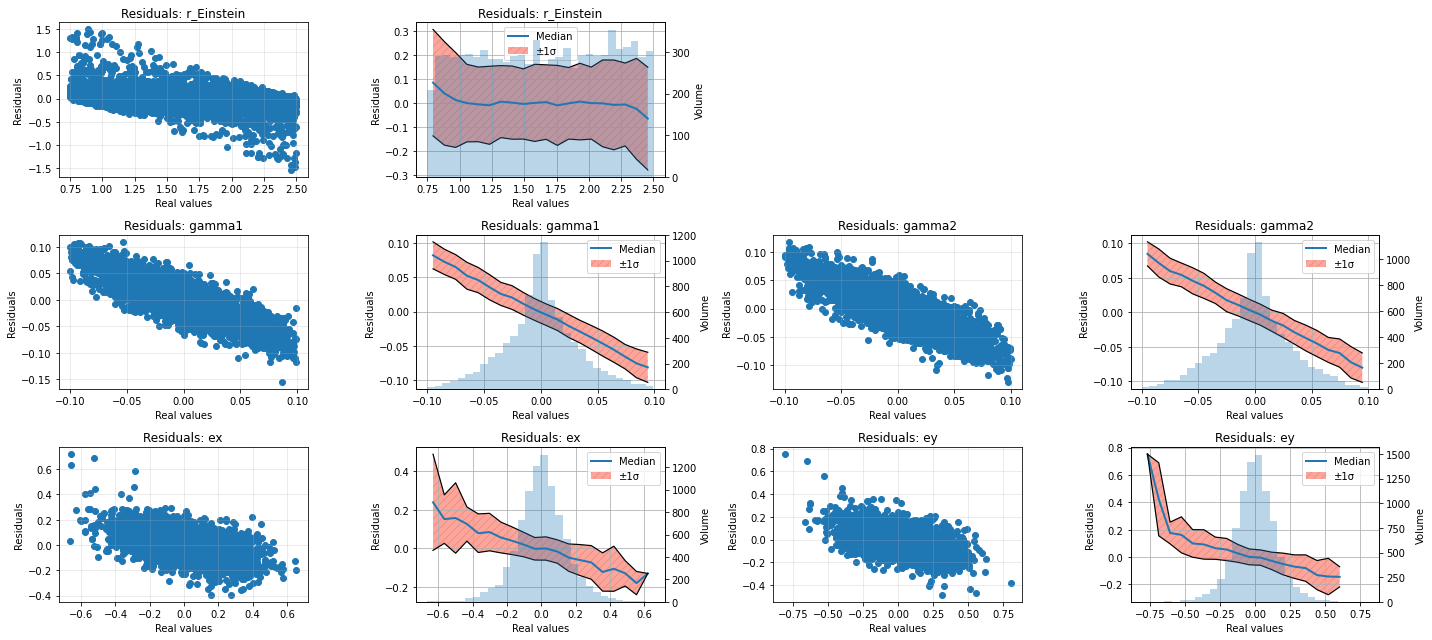

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min
error_denorm = y_pred_denorm - y_true_denorm

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(20, 9))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):
    plt.subplot(3, 4, places[i][0])
    plt.scatter(y_true_denorm[:,i], error_denorm[:,i])
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("Real values")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    
    # Extract the variables
    x = y_true_denorm[:, i]
    y = error_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Residuals")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Residuals: {param_names[i]}")

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residuals_vs_true_sqrt_13.png", dpi=300, bbox_inches="tight")
plt.show()
